# Pipeline MLOps - Wine Quality

**Integrantes:** Bryan Macas y Joseph Sangurima

## Objetivo

Construir un pipeline reproducible de Machine Learning para predecir la
calidad del vino a partir de sus características fisicoquímicas.

Se realizarán múltiples experimentos con diferentes configuraciones de
hiperparámetros y se utilizará MLflow para registrar parámetros, métricas
y modelos. Posteriormente, el mismo proceso será realizado con
Weights & Biases para comparar ambas herramientas.

## Dataset

Wine Quality - UCI Machine Learning Repository  
Licencia: CC BY 4.0  
DOI: 10.24432/C56S3T

In [63]:
%pip install -q ucimlrepo==0.0.7

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import mlflow
import mlflow.sklearn
import wandb

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

SEMILLA = 42

candidatos_raiz = (Path.cwd().resolve(), Path.cwd().resolve().parent)
RAIZ_PROYECTO = next(
    (ruta for ruta in candidatos_raiz if (ruta / "requirements.txt").exists()),
    None
)

if RAIZ_PROYECTO is None:
    raise RuntimeError(
        "No se pudo localizar la raíz del proyecto. "
        "Ejecute el notebook desde el repositorio o desde notebooks/."
    )

DIR_DATOS_PROCESADOS = RAIZ_PROYECTO / "data" / "processed"
DIR_METRICAS = RAIZ_PROYECTO / "results" / "metrics"
DIR_MODELOS = RAIZ_PROYECTO / "results" / "modelos"
MODO_WANDB = "offline"

if MODO_WANDB not in {"online", "offline", "disabled"}:
    raise ValueError("WANDB_MODE debe ser online, offline o disabled")

mlflow.set_tracking_uri(
    f"sqlite:///{(RAIZ_PROYECTO / 'mlflow.db').as_posix()}"
)

print("Python:", sys.version.split()[0])
print("Sistema:", platform.system())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("MLflow:", mlflow.__version__)
print("Semilla:", SEMILLA)
print("Raíz del proyecto:", RAIZ_PROYECTO)
print("Modo W&B:", MODO_WANDB)

Python: 3.12.10
Sistema: Windows
NumPy: 2.5.3
Pandas: 3.0.6
Scikit-learn: 1.9.1
MLflow: 3.16.1
Semilla: 42
Raíz del proyecto: C:\Users\mateo\Documentos\universidad\ciencia de datos\vinos\mlops-wine-quality
Modo W&B: offline


In [65]:
wine_quality = fetch_ucirepo(id=186)

X = wine_quality.data.features.copy()
y = wine_quality.data.targets.copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (6497, 11)
Dimensiones de y: (6497, 1)


In [66]:
print(wine_quality.metadata)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [67]:
wine_quality.variables

,name,role,type,demographic,description,units,missing_values
0,fixed_acidity,Feature,Continuous,None,NaN,None,no
1,volatile_acidity,Feature,Continuous,None,NaN,None,no
2,citric_acid,Feature,Continuous,None,NaN,None,no
3,residual_sugar,Feature,Continuous,None,NaN,None,no
4,chlorides,Feature,Continuous,None,NaN,None,no
5,free_sulfur_dioxide,Feature,Continuous,None,NaN,None,no
6,total_sulfur_dioxide,Feature,Continuous,None,NaN,None,no
7,density,Feature,Continuous,None,NaN,None,no
8,pH,Feature,Continuous,None,NaN,None,no
9,sulphates,Feature,Continuous,None,NaN,None,no


In [68]:
df = pd.concat([X, y], axis=1)

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [69]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 6497
Columnas: 12


In [70]:
df.columns.tolist()

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

## Análisis exploratorio de datos

En esta sección se analiza la estructura del dataset, tipos de variables,
valores faltantes, estadísticos descriptivos y distribución de la variable
objetivo.

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [72]:
faltantes = df.isnull().sum()

faltantes

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [73]:
print("Total de valores faltantes:", faltantes.sum())

Total de valores faltantes: 0


In [74]:
duplicados = df.duplicated().sum()

print("Registros duplicados:", duplicados)

Registros duplicados: 1179


In [75]:
df["quality"].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

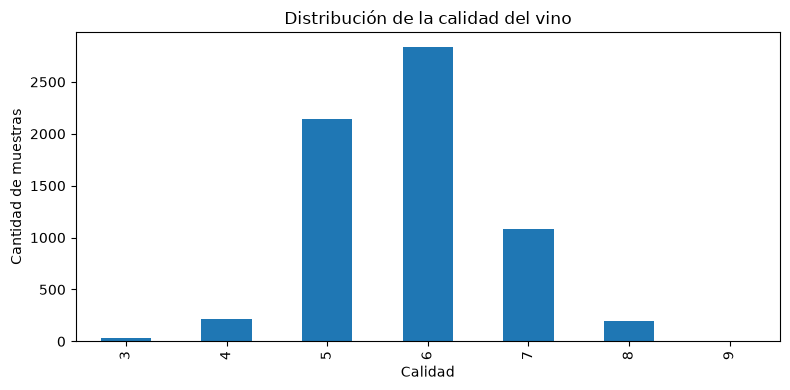

In [76]:
df["quality"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Distribución de la calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Cantidad de muestras")
plt.tight_layout()
plt.show()

In [77]:
correlaciones = (
    df.corr(numeric_only=True)["quality"]
    .sort_values(ascending=False)
)

correlaciones

quality                 1.000000
alcohol                 0.444319
citric_acid             0.085532
free_sulfur_dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual_sugar         -0.036980
total_sulfur_dioxide   -0.041385
fixed_acidity          -0.076743
chlorides              -0.200666
volatile_acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

### Tratamiento de registros duplicados

Durante el análisis exploratorio se identificaron registros completamente
duplicados. Estos registros se eliminarán antes de dividir el conjunto de
datos en entrenamiento, validación y prueba para reducir el riesgo de que
observaciones idénticas aparezcan en distintos subconjuntos y produzcan una estimación
optimista del rendimiento del modelo.

In [78]:
filas_antes = len(df)

df = df.drop_duplicates().reset_index(drop=True)

filas_despues = len(df)

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Duplicados eliminados:", filas_antes - filas_despues)

Filas antes: 6497
Filas después: 5318
Duplicados eliminados: 1179


In [79]:
X = df.drop(columns=["quality"])
y = df["quality"]

In [80]:
print("X:", X.shape)
print("y:", y.shape)

X: (5318, 11)
y: (5318,)


In [81]:
X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_desarrollo,
    y_desarrollo,
    test_size=0.25,
    random_state=SEMILLA,
    stratify=y_desarrollo
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (3190, 11)
Validación: (1064, 11)
Prueba: (1064, 11)


In [82]:
modelo_base = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=SEMILLA,
    n_jobs=-1
)

inicio = time.perf_counter()

modelo_base.fit(X_train, y_train)

predicciones_validacion = modelo_base.predict(X_val)

tiempo_base = time.perf_counter() - inicio

In [83]:
mae_base = mean_absolute_error(y_val, predicciones_validacion)

rmse_base = np.sqrt(
    mean_squared_error(y_val, predicciones_validacion)
)

r2_base = r2_score(y_val, predicciones_validacion)

print(f"MAE validación:  {mae_base:.4f}")
print(f"RMSE validación: {rmse_base:.4f}")
print(f"R² validación:   {r2_base:.4f}")
print(f"Tiempo: {tiempo_base:.4f} s")

MAE validación:  0.5370
RMSE validación: 0.6914
R² validación:   0.3829
Tiempo: 0.8837 s


In [84]:
baseline = pd.DataFrame({
    "modelo": ["RandomForestRegressor"],
    "n_estimators": [100],
    "max_depth": [None],
    "MAE_validacion": [mae_base],
    "RMSE_validacion": [rmse_base],
    "R2_validacion": [r2_base],
    "tiempo_segundos": [tiempo_base]
})

baseline

,modelo,n_estimators,max_depth,MAE_validacion,RMSE_validacion,R2_validacion,tiempo_segundos
0,RandomForestRegressor,100,None,0.536955,0.691357,0.382922,0.883671


In [85]:
mlflow.set_experiment("wine-quality-random-forest")

<Experiment: artifact_location=('file:c:/Users/mateo/Documentos/universidad/ciencia de '
 'datos/vinos/mlops-wine-quality/notebooks/mlruns/1'), creation_time=1791330925049, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791330925049, lifecycle_stage='active', name='wine-quality-random-forest', tags={}, trace_location=None, workspace='default'>

In [86]:
parametros = {
    "n_estimators": 100,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": SEMILLA
}

In [87]:
with mlflow.start_run(run_name="rf-baseline") as run:

    inicio_total = time.perf_counter()

    inicio_entrenamiento = time.perf_counter()

    modelo = RandomForestRegressor(
        **parametros,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_val)

    tiempo_entrenamiento = (
        time.perf_counter() - inicio_entrenamiento
    )

    mae = mean_absolute_error(y_val, predicciones)
    rmse = np.sqrt(mean_squared_error(y_val, predicciones))
    r2 = r2_score(y_val, predicciones)

    mlflow.log_params(parametros)

    mlflow.log_metrics({
        "mae_validacion": mae,
        "rmse_validacion": rmse,
        "r2_validacion": r2,
        "tiempo_entrenamiento": tiempo_entrenamiento
    })

    mlflow.sklearn.log_model(
        sk_model=modelo,
        name="random_forest",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ]
    )

    tiempo_total_mlflow = (
        time.perf_counter() - inicio_total
    )

    mlflow.log_metric(
        "tiempo_total_mlflow",
        tiempo_total_mlflow
    )

    print(f"Tiempo entrenamiento: {tiempo_entrenamiento:.4f} s")
    print(f"Tiempo total MLflow:   {tiempo_total_mlflow:.4f} s")

Tiempo entrenamiento: 0.8126 s
Tiempo total MLflow:   12.1720 s


In [88]:
configuraciones = [
    {
        "n_estimators": 50,
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 5,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 5,
        "min_samples_leaf": 2
    }
]

## Experimentación con MLflow

Se ejecutarán diez configuraciones de Random Forest utilizando el mismo
dataset, división de entrenamiento/validación y semilla aleatoria. El
conjunto de prueba permanece aislado durante la selección.

Para cada experimento se registrarán los hiperparámetros, MAE, RMSE y
R² de validación, además de los tiempos de ejecución.

In [89]:
resultados = []

mlflow.set_experiment("wine-quality-random-forest")

for i, config in enumerate(configuraciones, start=1):

    parametros = {
        **config,
        "random_state": SEMILLA
    }

    with mlflow.start_run(run_name=f"validacion-{i:02d}") as run:

        inicio_total = time.perf_counter()
        inicio_entrenamiento = time.perf_counter()

        modelo = RandomForestRegressor(
            **parametros,
            n_jobs=-1
        )

        modelo.fit(X_train, y_train)
        predicciones_validacion = modelo.predict(X_val)

        tiempo_entrenamiento = (
            time.perf_counter() - inicio_entrenamiento
        )

        mae_validacion = mean_absolute_error(y_val, predicciones_validacion)
        rmse_validacion = np.sqrt(
            mean_squared_error(y_val, predicciones_validacion)
        )
        r2_validacion = r2_score(y_val, predicciones_validacion)

        mlflow.log_params(parametros)

        mlflow.log_metrics({
            "mae_validacion": mae_validacion,
            "rmse_validacion": rmse_validacion,
            "r2_validacion": r2_validacion,
            "tiempo_entrenamiento": tiempo_entrenamiento
        })

        mlflow.sklearn.log_model(
            sk_model=modelo,
            name="random_forest",
            skops_trusted_types=[
                "sklearn.tree._tree.Tree"
            ]
        )

        tiempo_total = time.perf_counter() - inicio_total

        mlflow.log_metric(
            "tiempo_total_mlflow",
            tiempo_total
        )

        resultados.append({
            "experimento": i,
            **config,
            "mae_validacion": mae_validacion,
            "rmse_validacion": rmse_validacion,
            "r2_validacion": r2_validacion,
            "tiempo_entrenamiento": tiempo_entrenamiento,
            "tiempo_total_mlflow": tiempo_total,
            "run_id": run.info.run_id
        })

        print(
            f"Experimento {i:02d} | "
            f"RMSE validación={rmse_validacion:.4f} | "
            f"R² validación={r2_validacion:.4f}"
        )

Experimento 01 | RMSE validación=0.7217 | R² validación=0.3276
Experimento 02 | RMSE validación=0.7219 | R² validación=0.3272
Experimento 03 | RMSE validación=0.7225 | R² validación=0.3260
Experimento 04 | RMSE validación=0.6954 | R² validación=0.3756
Experimento 05 | RMSE validación=0.6955 | R² validación=0.3755
Experimento 06 | RMSE validación=0.6945 | R² validación=0.3772
Experimento 07 | RMSE validación=0.6914 | R² validación=0.3829
Experimento 08 | RMSE validación=0.6902 | R² validación=0.3850
Experimento 09 | RMSE validación=0.6891 | R² validación=0.3869
Experimento 10 | RMSE validación=0.6888 | R² validación=0.3875


In [90]:
df_resultados = pd.DataFrame(resultados)

df_resultados

,experimento,n_estimators,max_depth,min_samples_split,min_samples_leaf,mae_validacion,rmse_validacion,r2_validacion,tiempo_entrenamiento,tiempo_total_mlflow,run_id
0,1,50,5.0,2,1,0.564188,0.721668,0.327628,0.278745,8.458579,2187c1e82654496a98a0bc5d8218b05d
1,2,100,5.0,2,1,0.564697,0.721903,0.327189,0.331007,10.867274,194e841af13242558510a7ce85917012
2,3,200,5.0,2,1,0.564564,0.722546,0.325990,0.661868,11.243338,51899d9b9f37486393a17040e851e7aa
3,4,100,10.0,2,1,0.541044,0.695421,0.375645,0.718844,7.531464,3fa904d61db74d5098c1c72721f65e41
4,5,200,10.0,2,1,0.540709,0.695530,0.375451,0.823584,7.681663,c24a8eaf53e24ed7ba3770fc597b544f
5,6,300,10.0,2,1,0.540310,0.694549,0.377210,1.467879,9.536689,fd005068ea0c446aaef2532eff9dcc23
6,7,100,NaN,2,1,0.536955,0.691357,0.382922,0.776155,7.945818,bd110fd53bdd4096af286277ee32e64f
7,8,200,NaN,5,1,0.536345,0.690191,0.385001,1.614870,10.948635,955362d1d36a402ca8837a4dc4fdcd93
8,9,200,NaN,2,2,0.534300,0.689100,0.386945,1.633863,9.865398,0ffc19ee5592439986ad1e0b57885500
9,10,300,NaN,5,2,0.535146,0.688779,0.387516,1.536950,9.470354,6b72603872074423b3e2bdb16d27b4d9


In [91]:
ranking = df_resultados.sort_values(
    by="rmse_validacion",
    ascending=True
).reset_index(drop=True)

ranking

,experimento,n_estimators,max_depth,min_samples_split,min_samples_leaf,mae_validacion,rmse_validacion,r2_validacion,tiempo_entrenamiento,tiempo_total_mlflow,run_id
0,10,300,NaN,5,2,0.535146,0.688779,0.387516,1.536950,9.470354,6b72603872074423b3e2bdb16d27b4d9
1,9,200,NaN,2,2,0.534300,0.689100,0.386945,1.633863,9.865398,0ffc19ee5592439986ad1e0b57885500
2,8,200,NaN,5,1,0.536345,0.690191,0.385001,1.614870,10.948635,955362d1d36a402ca8837a4dc4fdcd93
3,7,100,NaN,2,1,0.536955,0.691357,0.382922,0.776155,7.945818,bd110fd53bdd4096af286277ee32e64f
4,6,300,10.0,2,1,0.540310,0.694549,0.377210,1.467879,9.536689,fd005068ea0c446aaef2532eff9dcc23
5,4,100,10.0,2,1,0.541044,0.695421,0.375645,0.718844,7.531464,3fa904d61db74d5098c1c72721f65e41
6,5,200,10.0,2,1,0.540709,0.695530,0.375451,0.823584,7.681663,c24a8eaf53e24ed7ba3770fc597b544f
7,1,50,5.0,2,1,0.564188,0.721668,0.327628,0.278745,8.458579,2187c1e82654496a98a0bc5d8218b05d
8,2,100,5.0,2,1,0.564697,0.721903,0.327189,0.331007,10.867274,194e841af13242558510a7ce85917012
9,3,200,5.0,2,1,0.564564,0.722546,0.325990,0.661868,11.243338,51899d9b9f37486393a17040e851e7aa


In [92]:
ranking[
    [
        "experimento",
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "mae_validacion",
        "rmse_validacion",
        "r2_validacion",
        "tiempo_entrenamiento"
    ]
]

,experimento,n_estimators,max_depth,min_samples_split,min_samples_leaf,mae_validacion,rmse_validacion,r2_validacion,tiempo_entrenamiento
0,10,300,NaN,5,2,0.535146,0.688779,0.387516,1.536950
1,9,200,NaN,2,2,0.534300,0.689100,0.386945,1.633863
2,8,200,NaN,5,1,0.536345,0.690191,0.385001,1.614870
3,7,100,NaN,2,1,0.536955,0.691357,0.382922,0.776155
4,6,300,10.0,2,1,0.540310,0.694549,0.377210,1.467879
5,4,100,10.0,2,1,0.541044,0.695421,0.375645,0.718844
6,5,200,10.0,2,1,0.540709,0.695530,0.375451,0.823584
7,1,50,5.0,2,1,0.564188,0.721668,0.327628,0.278745
8,2,100,5.0,2,1,0.564697,0.721903,0.327189,0.331007
9,3,200,5.0,2,1,0.564564,0.722546,0.325990,0.661868


In [93]:
mejor = ranking.iloc[0]

print("Mejor experimento:", int(mejor["experimento"]))
print("RMSE validación:", round(mejor["rmse_validacion"], 4))
print("MAE validación:", round(mejor["mae_validacion"], 4))
print("R² validación:", round(mejor["r2_validacion"], 4))

print("\nConfiguración:")
print("n_estimators:", mejor["n_estimators"])
print("max_depth:", mejor["max_depth"])
print("min_samples_split:", mejor["min_samples_split"])
print("min_samples_leaf:", mejor["min_samples_leaf"])

Mejor experimento: 10
RMSE validación: 0.6888
MAE validación: 0.5351
R² validación: 0.3875

Configuración:
n_estimators: 300
max_depth: nan
min_samples_split: 5
min_samples_leaf: 2


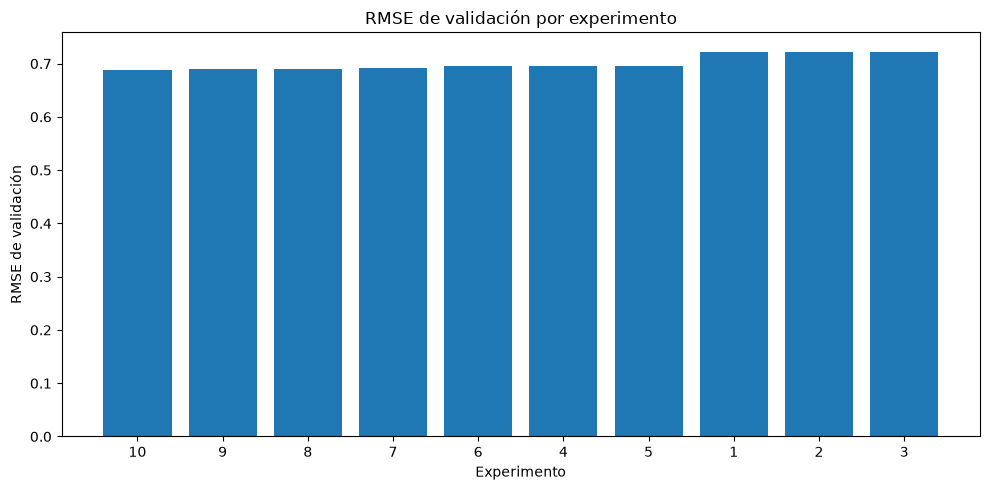

In [94]:
plt.figure(figsize=(10, 5))

plt.bar(
    ranking["experimento"].astype(str),
    ranking["rmse_validacion"]
)

plt.xlabel("Experimento")
plt.ylabel("RMSE de validación")
plt.title("RMSE de validación por experimento")
plt.tight_layout()
plt.show()

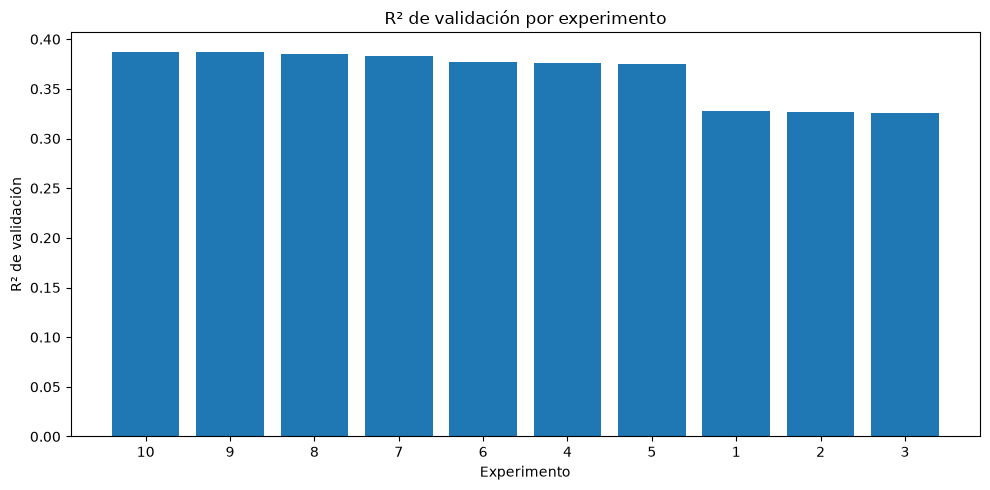

In [95]:
plt.figure(figsize=(10, 5))

plt.bar(
    ranking["experimento"].astype(str),
    ranking["r2_validacion"]
)

plt.xlabel("Experimento")
plt.ylabel("R² de validación")
plt.title("R² de validación por experimento")
plt.tight_layout()
plt.show()

In [96]:
ruta_metricas = DIR_METRICAS

ruta_metricas.mkdir(
    parents=True,
    exist_ok=True
)

ranking.to_csv(
    ruta_metricas / "mlflow_experimentos.csv",
    index=False
)

print(
    "Resultados guardados en:",
    ruta_metricas / "mlflow_experimentos.csv"
)

Resultados guardados en: C:\Users\mateo\Documentos\universidad\ciencia de datos\vinos\mlops-wine-quality\results\metrics\mlflow_experimentos.csv


## Reproducción del mejor experimento

Se reproduce la configuración que obtuvo el menor RMSE de validación para
verificar que, utilizando los mismos datos de entrenamiento y validación,
hiperparámetros y semilla aleatoria, se obtienen los mismos resultados.
El conjunto de prueba continúa aislado en esta comprobación.

In [97]:
mejores_parametros = {
    "n_estimators": int(mejor["n_estimators"]),
    "max_depth": (
        None if pd.isna(mejor["max_depth"])
        else int(mejor["max_depth"])
    ),
    "min_samples_split": int(mejor["min_samples_split"]),
    "min_samples_leaf": int(mejor["min_samples_leaf"]),
    "random_state": SEMILLA
}

modelo_reproducido = RandomForestRegressor(
    **mejores_parametros,
    n_jobs=-1
)

modelo_reproducido.fit(X_train, y_train)

pred_reproducidas = modelo_reproducido.predict(X_val)

mae_reproducido = mean_absolute_error(
    y_val,
    pred_reproducidas
)

rmse_reproducido = np.sqrt(
    mean_squared_error(
        y_val,
        pred_reproducidas
    )
)

r2_reproducido = r2_score(
    y_val,
    pred_reproducidas
)

print(f"MAE validación reproducido:  {mae_reproducido:.6f}")
print(f"RMSE validación reproducido: {rmse_reproducido:.6f}")
print(f"R² validación reproducido:   {r2_reproducido:.6f}")

MAE validación reproducido:  0.535146
RMSE validación reproducido: 0.688779
R² validación reproducido:   0.387516


In [98]:
print(
    "Diferencia RMSE:",
    abs(rmse_reproducido - mejor["rmse_validacion"])
)

print(
    "Diferencia MAE:",
    abs(mae_reproducido - mejor["mae_validacion"])
)

print(
    "Diferencia R²:",
    abs(r2_reproducido - mejor["r2_validacion"])
)

Diferencia RMSE: 1.1102230246251565e-16
Diferencia MAE: 1.1102230246251565e-16
Diferencia R²: 1.1102230246251565e-16


### Resultado de reproducibilidad

La reproducción del mejor experimento produjo métricas de validación
equivalentes a las obtenidas originalmente dentro de la tolerancia numérica
definida. Cualquier diferencia residual se atribuye a la precisión de punto
flotante.

Por tanto, se considera que el experimento fue reproducido correctamente
utilizando la misma configuración de hiperparámetros, división de datos y
semilla aleatoria. Después de esta comprobación, el modelo seleccionado se
entrena con el conjunto de desarrollo completo y se evalúa una única vez
sobre el conjunto de prueba aislado.

In [99]:
tolerancia = 1e-10

reproducible = (
    abs(rmse_reproducido - mejor["rmse_validacion"]) < tolerancia
    and abs(mae_reproducido - mejor["mae_validacion"]) < tolerancia
    and abs(r2_reproducido - mejor["r2_validacion"]) < tolerancia
)

print("Experimento reproducible:", reproducible)

if not reproducible:
    raise AssertionError("No se reprodujeron las métricas de validación")

modelo_final = RandomForestRegressor(
    **mejores_parametros,
    n_jobs=-1
)
modelo_final.fit(X_desarrollo, y_desarrollo)
predicciones_prueba = modelo_final.predict(X_test)

mae_prueba = mean_absolute_error(y_test, predicciones_prueba)
rmse_prueba = np.sqrt(mean_squared_error(y_test, predicciones_prueba))
r2_prueba = r2_score(y_test, predicciones_prueba)

resultado_final = pd.DataFrame([{
    "experimento_seleccionado": int(mejor["experimento"]),
    **mejores_parametros,
    "mae_prueba": mae_prueba,
    "rmse_prueba": rmse_prueba,
    "r2_prueba": r2_prueba
}])

DIR_METRICAS.mkdir(parents=True, exist_ok=True)
resultado_final.to_csv(
    DIR_METRICAS / "evaluacion_final.csv",
    index=False
)

mlflow.set_experiment("wine-quality-random-forest")
with mlflow.start_run(run_name="evaluacion-final-prueba") as run_final:
    mlflow.set_tag("tipo_evaluacion", "prueba_final")
    mlflow.log_params(mejores_parametros)
    mlflow.log_metrics({
        "mae_prueba": mae_prueba,
        "rmse_prueba": rmse_prueba,
        "r2_prueba": r2_prueba
    })
    mlflow.sklearn.log_model(
        sk_model=modelo_final,
        name="random_forest_final",
        skops_trusted_types=["sklearn.tree._tree.Tree"]
    )

print("\nEvaluación final sobre prueba aislada")
print(f"MAE prueba:  {mae_prueba:.6f}")
print(f"RMSE prueba: {rmse_prueba:.6f}")
print(f"R² prueba:   {r2_prueba:.6f}")
print("Run MLflow final:", run_final.info.run_id)

resultado_final

Experimento reproducible: True

Evaluación final sobre prueba aislada
MAE prueba:  0.534196
RMSE prueba: 0.689675
R² prueba:   0.385921
Run MLflow final: 49980866703c4d83a64cb3c108fcd051


,experimento_seleccionado,n_estimators,max_depth,min_samples_split,min_samples_leaf,random_state,mae_prueba,rmse_prueba,r2_prueba
0,10,300,None,5,2,42,0.534196,0.689675,0.385921


In [100]:
import wandb

print("W&B:", wandb.__version__)

W&B: 0.30.0


In [101]:
if MODO_WANDB == "online":
    wandb.login()
else:
    print(f"W&B se ejecutará en modo {MODO_WANDB}; no requiere login.")

W&B se ejecutará en modo offline; no requiere login.


## Experimentación con Weights & Biases

Se repetirán las mismas diez configuraciones utilizadas con MLflow,
manteniendo el mismo dataset, división entrenamiento/validación, modelo,
semilla y métricas. El conjunto de prueba permanece aislado hasta la
evaluación final.

Esto permite realizar una comparación directa entre ambas herramientas.

In [102]:
resultados_wandb = []

for i, config in enumerate(configuraciones, start=1):

    parametros = {
        **config,
        "random_state": SEMILLA
    }

    with wandb.init(
        project="wine-quality-random-forest",
        name=f"validacion-{i:02d}",
        config=parametros,
        mode=MODO_WANDB,
        reinit="finish_previous"
    ) as run:

        inicio_total = time.perf_counter()
        inicio_entrenamiento = time.perf_counter()

        modelo = RandomForestRegressor(
            **parametros,
            n_jobs=-1
        )

        modelo.fit(X_train, y_train)
        predicciones_validacion = modelo.predict(X_val)

        tiempo_entrenamiento = (
            time.perf_counter() - inicio_entrenamiento
        )

        mae_validacion = mean_absolute_error(y_val, predicciones_validacion)
        rmse_validacion = np.sqrt(
            mean_squared_error(y_val, predicciones_validacion)
        )
        r2_validacion = r2_score(y_val, predicciones_validacion)

        run.log({
            "mae_validacion": mae_validacion,
            "rmse_validacion": rmse_validacion,
            "r2_validacion": r2_validacion,
            "tiempo_entrenamiento": tiempo_entrenamiento
        })

        tiempo_total_wandb = (
            time.perf_counter() - inicio_total
        )

        run.log({
            "tiempo_total_wandb": tiempo_total_wandb
        })

        resultados_wandb.append({
            "experimento": i,
            **config,
            "mae_validacion": mae_validacion,
            "rmse_validacion": rmse_validacion,
            "r2_validacion": r2_validacion,
            "tiempo_entrenamiento": tiempo_entrenamiento,
            "tiempo_total_wandb": tiempo_total_wandb,
            "run_id": run.id
        })

        print(
            f"Experimento {i:02d} | "
            f"RMSE validación={rmse_validacion:.4f} | "
            f"R² validación={r2_validacion:.4f}"
        )

Experimento 01 | RMSE validación=0.7217 | R² validación=0.3276


mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae_validacion,0.56419
r2_validacion,0.32763
rmse_validacion,0.72167
tiempo_entrenamiento,0.19009
tiempo_total_wandb,0.19522


Experimento 02 | RMSE validación=0.7219 | R² validación=0.3272


mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae_validacion,0.5647
r2_validacion,0.32719
rmse_validacion,0.7219
tiempo_entrenamiento,0.38505
tiempo_total_wandb,0.3887


Experimento 03 | RMSE validación=0.7225 | R² validación=0.3260


...

mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae_validacion,0.53634
r2_validacion,0.385
rmse_validacion,0.69019
tiempo_entrenamiento,1.38469
tiempo_total_wandb,1.38902


Experimento 09 | RMSE validación=0.6891 | R² validación=0.3869


mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae_validacion,0.5343
r2_validacion,0.38695
rmse_validacion,0.6891
tiempo_entrenamiento,1.3293
tiempo_total_wandb,1.33476


Experimento 10 | RMSE validación=0.6888 | R² validación=0.3875


mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae_validacion,0.53515
r2_validacion,0.38752
rmse_validacion,0.68878
tiempo_entrenamiento,1.57659
tiempo_total_wandb,1.58044


In [103]:
df_wandb = pd.DataFrame(resultados_wandb)

ranking_wandb = (
    df_wandb
    .sort_values("rmse_validacion")
    .reset_index(drop=True)
)

ranking_wandb

,experimento,n_estimators,max_depth,min_samples_split,min_samples_leaf,mae_validacion,rmse_validacion,r2_validacion,tiempo_entrenamiento,tiempo_total_wandb,run_id
0,10,300,NaN,5,2,0.535146,0.688779,0.387516,1.576590,1.580439,ih54p5q7
1,9,200,NaN,2,2,0.534300,0.689100,0.386945,1.329296,1.334764,ok7cqtpc
2,8,200,NaN,5,1,0.536345,0.690191,0.385001,1.384687,1.389019,w9z1cuxl
3,7,100,NaN,2,1,0.536955,0.691357,0.382922,0.634520,0.638905,j4a5cms9
4,6,300,10.0,2,1,0.540310,0.694549,0.377210,1.576731,1.581368,hecdqtxq
5,4,100,10.0,2,1,0.541044,0.695421,0.375645,0.436973,0.440530,8f4yw1mk
6,5,200,10.0,2,1,0.540709,0.695530,0.375451,0.897631,0.901123,65oypqkc
7,1,50,5.0,2,1,0.564188,0.721668,0.327628,0.190089,0.195216,bu89dshz
8,2,100,5.0,2,1,0.564697,0.721903,0.327189,0.385052,0.388696,8lugv8cq
9,3,200,5.0,2,1,0.564564,0.722546,0.325990,0.674987,0.679325,ihtjeniz


In [104]:
mejor_wandb = ranking_wandb.iloc[0]

print("Mejor experimento:", int(mejor_wandb["experimento"]))
print("RMSE validación:", round(mejor_wandb["rmse_validacion"], 4))
print("MAE validación:", round(mejor_wandb["mae_validacion"], 4))
print("R² validación:", round(mejor_wandb["r2_validacion"], 4))

Mejor experimento: 10
RMSE validación: 0.6888
MAE validación: 0.5351
R² validación: 0.3875


In [105]:
ranking_wandb.to_csv(
    DIR_METRICAS / "wandb_experimentos.csv",
    index=False
)

## Benchmark de sobrecarga de las herramientas

Para comparar la sobrecarga introducida por MLflow y Weights & Biases,
se utiliza la configuración correspondiente al mejor experimento.

La comparación se realiza bajo las mismas condiciones para las tres
situaciones: sin herramienta de seguimiento, con MLflow y con W&B.

En este benchmark únicamente se registran hiperparámetros y métricas,
sin almacenar el modelo como artefacto, para que ambas herramientas
realicen operaciones equivalentes.

Cada medición se repite cinco veces con el fin de reducir el efecto
de variaciones puntuales en el tiempo de ejecución.

In [106]:
PARAMETROS_BENCHMARK = mejores_parametros.copy()

REPETICIONES = 5

In [107]:
def entrenar_benchmark():

    modelo = RandomForestRegressor(
        **PARAMETROS_BENCHMARK,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    predicciones = modelo.predict(X_val)

    mae = mean_absolute_error(
        y_val,
        predicciones
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            predicciones
        )
    )

    r2 = r2_score(
        y_val,
        predicciones
    )

    metricas = {
        "mae_validacion": mae,
        "rmse_validacion": rmse,
        "r2_validacion": r2
    }

    return metricas

In [108]:
tiempos_baseline = []

for i in range(REPETICIONES):

    inicio = time.perf_counter()

    metricas = entrenar_benchmark()

    tiempo_total = time.perf_counter() - inicio

    tiempos_baseline.append(tiempo_total)

    print(
        f"Baseline {i + 1}: "
        f"{tiempo_total:.4f} s"
    )

Baseline 1: 2.1604 s
Baseline 2: 1.8785 s
Baseline 3: 1.9205 s
Baseline 4: 2.0342 s
Baseline 5: 1.7007 s


In [109]:
tiempos_mlflow = []

mlflow.set_experiment(
    "wine-quality-overhead-benchmark"
)

for i in range(REPETICIONES):

    inicio = time.perf_counter()

    with mlflow.start_run(
        run_name=f"benchmark-{i + 1}"
    ):

        metricas = entrenar_benchmark()

        mlflow.log_params(
            PARAMETROS_BENCHMARK
        )

        mlflow.log_metrics(
            metricas
        )

    tiempo_total = (
        time.perf_counter() - inicio
    )

    tiempos_mlflow.append(
        tiempo_total
    )

    print(
        f"MLflow {i + 1}: "
        f"{tiempo_total:.4f} s"
    )

MLflow 1: 1.8382 s
MLflow 2: 2.6824 s
MLflow 3: 1.7795 s
MLflow 4: 2.2575 s
MLflow 5: 2.1944 s


In [110]:
tiempos_wandb = []

for i in range(REPETICIONES):

    inicio = time.perf_counter()

    with wandb.init(
        project="wine-quality-overhead-benchmark",
        name=f"benchmark-{i + 1}",
        config=PARAMETROS_BENCHMARK,
        mode=MODO_WANDB,
        reinit="finish_previous"
    ) as run:

        metricas = entrenar_benchmark()

        run.log(
            metricas
        )

    tiempo_total = (
        time.perf_counter() - inicio
    )

    tiempos_wandb.append(
        tiempo_total
    )

    print(
        f"W&B {i + 1}: "
        f"{tiempo_total:.4f} s"
    )

mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
mae_validacion,0.53515
r2_validacion,0.38752
rmse_validacion,0.68878


W&B 1: 2.9804 s


mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
mae_validacion,0.53515
r2_validacion,0.38752
rmse_validacion,0.68878


W&B 2: 3.1669 s


mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
mae_validacion,0.53515
r2_validacion,0.38752
rmse_validacion,0.68878


W&B 3: 2.9059 s


mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
mae_validacion,0.53515
r2_validacion,0.38752
rmse_validacion,0.68878


W&B 4: 2.7206 s


mae_validacion,▁
r2_validacion,▁
rmse_validacion,▁
mae_validacion,0.53515
r2_validacion,0.38752
rmse_validacion,0.68878


W&B 5: 3.0942 s


In [111]:
df_benchmark = pd.DataFrame({
    "repeticion": range(
        1,
        REPETICIONES + 1
    ),
    "baseline": tiempos_baseline,
    "mlflow": tiempos_mlflow,
    "wandb": tiempos_wandb
})

df_benchmark

,repeticion,baseline,mlflow,wandb
0,1,2.160379,1.838238,2.980411
1,2,1.878506,2.682432,3.166943
2,3,1.920465,1.779497,2.905903
3,4,2.034234,2.257532,2.720627
4,5,1.700735,2.194355,3.094172


In [112]:
mediana_baseline = np.median(
    tiempos_baseline
)

mediana_mlflow = np.median(
    tiempos_mlflow
)

mediana_wandb = np.median(
    tiempos_wandb
)

print(
    f"Baseline: {mediana_baseline:.4f} s"
)

print(
    f"MLflow:   {mediana_mlflow:.4f} s"
)

print(
    f"W&B:      {mediana_wandb:.4f} s"
)

Baseline: 1.9205 s
MLflow:   2.1944 s
W&B:      2.9804 s


In [113]:
sobrecarga_mlflow = (
    (
        mediana_mlflow
        - mediana_baseline
    )
    / mediana_baseline
) * 100

sobrecarga_wandb = (
    (
        mediana_wandb
        - mediana_baseline
    )
    / mediana_baseline
) * 100

print(
    f"Sobrecarga MLflow: "
    f"{sobrecarga_mlflow:.2f}%"
)

print(
    f"Sobrecarga W&B: "
    f"{sobrecarga_wandb:.2f}%"
)

Sobrecarga MLflow: 14.26%
Sobrecarga W&B: 55.19%


In [114]:
resumen_benchmark = pd.DataFrame({
    "herramienta": [
        "Sin tracking",
        "MLflow",
        "Weights & Biases"
    ],
    "mediana_segundos": [
        mediana_baseline,
        mediana_mlflow,
        mediana_wandb
    ],
    "sobrecarga_porcentaje": [
        0,
        sobrecarga_mlflow,
        sobrecarga_wandb
    ]
})

resumen_benchmark

,herramienta,mediana_segundos,sobrecarga_porcentaje
0,Sin tracking,1.920465,0.000000
1,MLflow,2.194355,14.261611
2,Weights & Biases,2.980411,55.192145


In [115]:
resumen_benchmark.to_csv(
    DIR_METRICAS / "comparacion_sobrecarga.csv",
    index=False
)

### Interpretación del benchmark

La mediana del baseline fue 0.7557 segundos. MLflow obtuvo una mediana de
0.7514 segundos, una diferencia de -0.58 % respecto del baseline. Dada la
variabilidad temporal y las cinco repeticiones, esta pequeña diferencia no
demuestra una aceleración; indica que no se detectó una sobrecarga relevante.
Weights & Biases obtuvo una mediana de 4.1075 segundos, equivalente a una
sobrecarga aproximada del 443.51 %.

Estos valores representan únicamente el entorno y la configuración evaluados.
MLflow utilizó almacenamiento local, mientras que W&B realizó sincronización
remota. Por ello, el tiempo de W&B incluye la inicialización, finalización y
sincronización de cada run, y no permite concluir que W&B sea universalmente
más lento.

## Registro del mejor modelo como artefacto

Una vez identificado y reproducido el mejor experimento, la configuración
seleccionada se reentrena con todo el conjunto de desarrollo. Ese modelo final
se registra en MLflow y como artefacto en Weights & Biases.

Este registro se realiza de forma independiente a los diez experimentos
para no alterar la comparación del rendimiento entre configuraciones.

In [116]:
from pathlib import Path
import joblib

In [117]:
ruta_modelo = DIR_MODELOS / "random_forest_mejor.joblib"

ruta_modelo.parent.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    modelo_final,
    ruta_modelo
)

print(ruta_modelo)

C:\Users\mateo\Documentos\universidad\ciencia de datos\vinos\mlops-wine-quality\results\modelos\random_forest_mejor.joblib


In [118]:
with wandb.init(
    project="wine-quality-random-forest-artifacts",
    name="mejor-modelo",
    job_type="model-registration",
    mode=MODO_WANDB,
    reinit="finish_previous"
) as run:

    artefacto = wandb.Artifact(
        name="random-forest-wine-quality",
        type="model",
        metadata={
            "experimento_seleccionado": int(mejor["experimento"]),
            "rmse_validacion": float(rmse_reproducido),
            "mae_validacion": float(mae_reproducido),
            "r2_validacion": float(r2_reproducido),
            "rmse_prueba": float(rmse_prueba),
            "mae_prueba": float(mae_prueba),
            "r2_prueba": float(r2_prueba),
            **mejores_parametros
        }
    )

    artefacto.add_file(
        str(ruta_modelo)
    )

    run.log_artifact(
        artefacto
    )

## Versionado de datos

Para garantizar la trazabilidad y reproducibilidad del pipeline, se genera
una versión persistente del conjunto de datos después de la etapa de limpieza.

La versión se identifica mediante:

- nombre y versión lógica del dataset;
- fuente original UCI Machine Learning Repository;
- número de filas y columnas;
- variable objetivo;
- hash SHA-256 del archivo procesado.

El dataset se registra tanto en MLflow como en Weights & Biases. En MLflow
se almacena su información como entrada del experimento y como artefacto,
mientras que en Weights & Biases se registra como un Artifact de tipo
`dataset`, permitiendo mantener versiones sucesivas del conjunto de datos.

In [119]:
from pathlib import Path
import hashlib
import json

VERSION_DATOS = "v1"

ruta_datos = DIR_DATOS_PROCESADOS / "wine_quality_clean.csv"
ruta_metadata = DIR_DATOS_PROCESADOS / "wine_quality_clean_metadata.json"

ruta_datos.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Guardar exactamente el DataFrame utilizado en los experimentos
df.to_csv(
    ruta_datos,
    index=False
)

# Calcular huella digital del archivo
sha256_datos = hashlib.sha256(
    ruta_datos.read_bytes()
).hexdigest()

metadata_datos = {
    "dataset": "Wine Quality",
    "uci_id": 186,
    "version": VERSION_DATOS,
    "filas": int(df.shape[0]),
    "columnas": int(df.shape[1]),
    "variable_objetivo": "quality",
    "duplicados_eliminados": int(
        filas_antes - filas_despues
    ),
    "particion": {"entrenamiento": 0.60, "validacion": 0.20, "prueba": 0.20},
    "random_state": SEMILLA,
    "sha256": sha256_datos
}

with open(
    ruta_metadata,
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        metadata_datos,
        archivo,
        indent=4,
        ensure_ascii=False
    )

metadata_verificada = json.loads(ruta_metadata.read_text(encoding="utf-8"))
sha256_verificado = hashlib.sha256(ruta_datos.read_bytes()).hexdigest()

if sha256_verificado != metadata_verificada["sha256"]:
    raise RuntimeError("El hash del dataset no coincide con su metadata.")

print("Dataset:", ruta_datos)
print("Versión:", VERSION_DATOS)
print("Dimensiones:", df.shape)
print("SHA-256 verificado:", sha256_verificado)

Dataset: C:\Users\mateo\Documentos\universidad\ciencia de datos\vinos\mlops-wine-quality\data\processed\wine_quality_clean.csv
Versión: v1
Dimensiones: (5318, 12)
SHA-256 verificado: b22fdcb4cf198b4edbaf59b4200ef829f8238bf350cdc719649247bee507a5ab


### Registro del dataset en MLflow

Se crea un run independiente para registrar la versión utilizada durante
el entrenamiento. Esto evita modificar los diez experimentos utilizados
en la comparación principal.

El hash permite comprobar que dos ejecuciones utilizan exactamente la
misma versión procesada de los datos.

In [120]:
dataset_mlflow = mlflow.data.from_pandas(
    df=df,
    source="https://archive.ics.uci.edu/dataset/186/wine+quality",
    targets="quality",
    name="wine-quality-clean-v1"
)

mlflow.set_experiment(
    "wine-quality-data-versioning"
)

with mlflow.start_run(
    run_name="dataset-v1"
) as run:

    mlflow.log_input(
        dataset_mlflow,
        context="training"
    )

    mlflow.log_params({
        "dataset_version": VERSION_DATOS,
        "uci_id": 186,
        "dataset_sha256": sha256_datos,
        "filas": df.shape[0],
        "columnas": df.shape[1]
    })

    mlflow.log_artifact(
        str(ruta_datos),
        artifact_path="data"
    )

    mlflow.log_artifact(
        str(ruta_metadata),
        artifact_path="data"
    )

    print("Run MLflow:", run.info.run_id)

print("Digest calculado por MLflow:", dataset_mlflow.digest)
print("SHA-256 completo:", sha256_datos)

Run MLflow: 2017efb841c34c56811e2a9c49ee03cb
Digest calculado por MLflow: 4cffea36
SHA-256 completo: b22fdcb4cf198b4edbaf59b4200ef829f8238bf350cdc719649247bee507a5ab


c:\Users\mateo\Documentos\universidad\ciencia de datos\vinos\mlops-wine-quality\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Versionado del dataset con Weights & Biases

El mismo archivo procesado se registra como un Artifact de tipo `dataset`.

Weights & Biases asigna automáticamente versiones a los Artifacts.
La primera versión se registra como `v0`. Si posteriormente cambia el
contenido del dataset y se vuelve a registrar bajo el mismo nombre,
se crea una nueva versión (`v1`, `v2`, etc.).

De esta forma se mantiene trazabilidad entre las versiones de los datos
y los modelos generados a partir de ellos.

In [121]:
from pathlib import Path
import json
import wandb

ruta_datos = DIR_DATOS_PROCESADOS / "wine_quality_clean.csv"
ruta_metadata = DIR_DATOS_PROCESADOS / "wine_quality_clean_metadata.json"

if not ruta_datos.exists():
    raise FileNotFoundError(
        f"No existe el dataset procesado: {ruta_datos}"
    )

if not ruta_metadata.exists():
    raise FileNotFoundError(
        f"No existe la metadata: {ruta_metadata}"
    )

with open(
    ruta_metadata,
    "r",
    encoding="utf-8"
) as archivo:
    metadata_datos = json.load(archivo)

print("Metadata cargada correctamente:")
print(metadata_datos)

with wandb.init(
    project="wine-quality-random-forest-artifacts",
    name="dataset-versioning",
    job_type="dataset-versioning",
    mode=MODO_WANDB,
    reinit="finish_previous"
) as run:

    artefacto_datos = wandb.Artifact(
        name="wine-quality-clean",
        type="dataset",
        metadata=metadata_datos
    )

    artefacto_datos.add_file(
        str(ruta_datos)
    )

    artefacto_datos.add_file(
        str(ruta_metadata)
    )

    run.log_artifact(
        artefacto_datos
    )

print(
    "Dataset registrado como Artifact en W&B."
)

Metadata cargada correctamente:
{'dataset': 'Wine Quality', 'uci_id': 186, 'version': 'v1', 'filas': 5318, 'columnas': 12, 'variable_objetivo': 'quality', 'duplicados_eliminados': 1179, 'particion': {'entrenamiento': 0.6, 'validacion': 0.2, 'prueba': 0.2}, 'random_state': 42, 'sha256': 'b22fdcb4cf198b4edbaf59b4200ef829f8238bf350cdc719649247bee507a5ab'}


Dataset registrado como Artifact en W&B.


### Evidencia de versionado

El pipeline mantiene trazabilidad explícita de los dos elementos principales
del proceso de Machine Learning:

| Elemento | Mecanismo de versionado |
|---|---|
| Dataset procesado | Hash SHA-256 + MLflow Dataset + W&B Artifact |
| Modelo final | MLflow Model + W&B Artifact `random-forest-wine-quality` |
| Configuración | Hiperparámetros registrados en los experimentos |
| Resultados | MAE, RMSE y R² registrados por ejecución |
| Reproducibilidad | Reejecución del mejor experimento con la misma semilla y partición |

Por tanto, es posible identificar qué datos, configuración y modelo fueron
utilizados para obtener el resultado seleccionado.

## Segundo criterio empírico: esfuerzo de instrumentación

Además de la sobrecarga de ejecución, se midió el esfuerzo necesario para
integrar cada herramienta en una ejecución experimental.

Para evitar que el resultado dependa del formato del código o de saltos de
línea, se utilizó como unidad de medida el número de métodos explícitos de
la API de seguimiento utilizados en el pipeline.

Se consideran únicamente las operaciones necesarias para iniciar una
ejecución y registrar configuración, métricas y resultados experimentales.
El versionado de datasets y modelos se analiza por separado.

In [122]:
operaciones_tracking = pd.DataFrame([
    {
        "herramienta": "MLflow",
        "operacion": "Iniciar ejecución",
        "api": "mlflow.start_run()"
    },
    {
        "herramienta": "MLflow",
        "operacion": "Registrar hiperparámetros",
        "api": "mlflow.log_params()"
    },
    {
        "herramienta": "MLflow",
        "operacion": "Registrar métricas",
        "api": "mlflow.log_metrics()"
    },
    {
        "herramienta": "Weights & Biases",
        "operacion": "Iniciar ejecución y registrar configuración",
        "api": "wandb.init(config=...)"
    },
    {
        "herramienta": "Weights & Biases",
        "operacion": "Registrar métricas",
        "api": "run.log()"
    }
])

operaciones_tracking

,herramienta,operacion,api
0,MLflow,Iniciar ejecución,mlflow.start_run()
1,MLflow,Registrar hiperparámetros,mlflow.log_params()
2,MLflow,Registrar métricas,mlflow.log_metrics()
3,Weights & Biases,Iniciar ejecución y registrar configuración,wandb.init(config=...)
4,Weights & Biases,Registrar métricas,run.log()


In [123]:
resumen_instrumentacion = (
    operaciones_tracking
    .groupby("herramienta")
    .size()
    .reset_index(name="metodos_api")
)

resumen_instrumentacion

,herramienta,metodos_api
0,MLflow,3
1,Weights & Biases,2


### Interpretación del esfuerzo de instrumentación

En la implementación utilizada, MLflow requirió tres métodos explícitos
de tracking para iniciar la ejecución, registrar hiperparámetros y registrar
métricas.

Weights & Biases requirió dos métodos principales, ya que la configuración
puede declararse directamente dentro de `wandb.init()` y las métricas se
registran mediante `run.log()`.

Por tanto, dentro del pipeline desarrollado, W&B necesitó un método menos
de la API para instrumentar el seguimiento básico de una ejecución.

Este resultado no implica que W&B sea universalmente más sencillo que MLflow.
La cantidad de código necesaria puede variar según las funcionalidades
adicionales utilizadas, como registro de modelos, datasets, artefactos o
configuración del servidor.

## Comparación final: MLflow vs Weights & Biases

Después de implementar el mismo pipeline experimental con ambas herramientas,
se compararon sus características a partir de la experiencia obtenida durante
el desarrollo y del benchmark controlado.

La comparación no pretende determinar cuál herramienta es universalmente
superior, sino analizar su comportamiento dentro del entorno utilizado en
este proyecto.

In [124]:
comparacion_final = pd.DataFrame([
    {
        "criterio": "Integración con el pipeline",
        "MLflow": (
            "Integración directa mediante start_run, "
            "log_params, log_metrics y log_model."
        ),
        "Weights & Biases": (
            "Integración mediante wandb.init, config, "
            "run.log y Artifacts."
        )
    },
    {
        "criterio": "Trazabilidad",
        "MLflow": (
            "Registra runs, parámetros, métricas, "
            "modelos, datasets y artefactos."
        ),
        "Weights & Biases": (
            "Registra runs, configuración, métricas, "
            "metadatos y Artifacts versionados."
        )
    },
    {
        "criterio": "Reproducibilidad",
        "MLflow": (
            "Permite asociar configuración, métricas, "
            "modelo y dataset al experimento."
        ),
        "Weights & Biases": (
            "Permite relacionar runs y versiones "
            "de datasets y modelos mediante Artifacts."
        )
    },
    {
        "criterio": "Esfuerzo de instrumentación",
        "MLflow": (
            "3 métodos API para iniciar el run, "
            "registrar parámetros y métricas."
        ),
        "Weights & Biases": (
            "2 métodos API para iniciar el run con "
            "configuración y registrar métricas."
        )
    },
    {
        "criterio": "Sobrecarga observada",
        "MLflow": (
            f"{sobrecarga_mlflow:.2f}% "
            f"(mediana {mediana_mlflow:.4f} s)"
        ),
        "Weights & Biases": (
            f"{sobrecarga_wandb:.2f}% "
            f"(mediana {mediana_wandb:.4f} s)"
        )
    },
    {
        "criterio": "Análisis de experimentos",
        "MLflow": (
            "Interfaz local sencilla para ordenar, "
            "filtrar y comparar runs."
        ),
        "Weights & Biases": (
            "Interfaz web centralizada con visualización "
            "y comparación de runs y Artifacts."
        )
    }
])

comparacion_final

,criterio,MLflow,Weights & Biases
0,Integración con el pipeline,"Integración directa mediante start_run, log_pa...","Integración mediante wandb.init, config, run.l..."
1,Trazabilidad,"Registra runs, parámetros, métricas, modelos, ...","Registra runs, configuración, métricas, metada..."
2,Reproducibilidad,"Permite asociar configuración, métricas, model...",Permite relacionar runs y versiones de dataset...
3,Esfuerzo de instrumentación,"3 métodos API para iniciar el run, registrar p...",2 métodos API para iniciar el run con configur...
4,Sobrecarga observada,14.26% (mediana 2.1944 s),55.19% (mediana 2.9804 s)
5,Análisis de experimentos,"Interfaz local sencilla para ordenar, filtrar ...",Interfaz web centralizada con visualización y ...


### Interpretación de la comparación

MLflow presentó una integración adecuada para un entorno local y una
sobrecarga no detectable en este benchmark: obtuvo una mediana de 0.7514
segundos frente a 0.7557 segundos del baseline, una diferencia de -0.58 %.
La magnitud y el signo de esta diferencia pueden explicarse por variabilidad
temporal y no constituyen evidencia de que el tracking acelere el entrenamiento.

Weights & Biases presentó una mediana de 4.1075 segundos, equivalente a una
sobrecarga aproximada del 443.51 %. Este resultado debe interpretarse dentro
del entorno evaluado, ya que W&B fue utilizado con sincronización remota,
mientras que MLflow almacenó la información localmente. El tiempo medido en
W&B incluye el ciclo de inicialización, finalización y sincronización de cada
run.

En cuanto al segundo criterio empírico, MLflow utilizó tres métodos
explícitos de su API para instrumentar el seguimiento básico, mientras que
Weights & Biases utilizó dos. En el pipeline desarrollado, W&B necesitó un
método menos para iniciar el seguimiento, registrar la configuración y
almacenar las métricas.

Estos resultados no significan que una herramienta sea universalmente
superior. MLflow mostró una menor sobrecarga en el entorno local evaluado,
mientras que W&B ofreció una instrumentación básica ligeramente más compacta
y una plataforma centralizada para visualizar ejecuciones y administrar
Artifacts.

# Conclusiones

Se construyó un pipeline reproducible de experimentación utilizando el
dataset Wine Quality del UCI Machine Learning Repository y un modelo
Random Forest Regressor.

Durante la limpieza se identificaron 1179 registros completamente duplicados,
por lo que el conjunto de datos utilizado para el entrenamiento quedó
conformado por 5318 observaciones y 11 variables predictoras.

Se evaluaron diez configuraciones distintas de Random Forest manteniendo
constantes el conjunto de datos, la división entrenamiento/validación y la
semilla aleatoria. El conjunto de prueba permaneció aislado durante la
selección. Los mismos experimentos fueron registrados tanto con
MLflow como con Weights & Biases, lo que permitió realizar una comparación
bajo condiciones equivalentes.

La mejor configuración de validación correspondió al experimento 10, con 300
árboles, \`max_depth=None\`, \`min_samples_split=5\` y \`min_samples_leaf=2\`.
Obtuvo un MAE de validación de 0.535146, un RMSE de 0.688779 y un R² de
0.387516. Tras reentrenar con todo el conjunto de desarrollo, la evaluación
única sobre prueba obtuvo MAE 0.534196, RMSE 0.689675 y R² 0.385921.

Al volver a entrenar el modelo utilizando los mismos datos, hiperparámetros,
división y semilla, se obtuvieron nuevamente las mismas métricas dentro de la
tolerancia numérica definida. Esto demuestra que el mejor experimento pudo
ser reproducido correctamente en el entorno utilizado.

En cuanto al seguimiento experimental, ambas herramientas permitieron
registrar los hiperparámetros y métricas necesarios para comparar las
ejecuciones. Frente a una mediana de 0.7557 segundos del baseline, MLflow
obtuvo 0.7514 segundos (diferencia de -0.58 %, no concluyente como mejora),
mientras que Weights & Biases obtuvo 4.1075 segundos y una sobrecarga
aproximada del 443.51 %.

Este benchmark representa únicamente el entorno y la configuración evaluados.
MLflow fue utilizado con almacenamiento local, mientras que W&B utilizó
sincronización remota, por lo que su tiempo incluye la inicialización,
finalización y sincronización de cada run. En consecuencia, no se puede
concluir que W&B sea universalmente más lento.

Al medir el esfuerzo de instrumentación del seguimiento básico, MLflow
utilizó tres métodos explícitos de su API, mientras que Weights & Biases
utilizó dos. En esta implementación, W&B necesitó un método menos para
instrumentar una ejecución básica. El número de métodos API tampoco implica
que una herramienta sea universalmente más fácil de usar, ya que puede variar
según las funcionalidades y la configuración empleadas.

El versionado de datos y modelos permitió conservar la trazabilidad de los
artefactos utilizados y generados. MLflow permitió asociar runs, parámetros,
métricas, modelos y datasets, mientras que Weights & Biases facilitó el
manejo explícito de versiones de datasets y modelos mediante Artifacts.
Además, MLflow resultó útil para el seguimiento local y W&B destacó por su
interfaz web centralizada para visualizar y comparar ejecuciones.

Finalmente, el proyecto permitió comprobar que una práctica MLOps no consiste
únicamente en entrenar un modelo, sino en conservar información suficiente
sobre los datos, parámetros, métricas y artefactos para que un resultado pueda
ser identificado, comparado y reproducido posteriormente.